<a href="https://colab.research.google.com/github/Aayan783/BrainTumourDetection/blob/main/NormalandAcuteBrainMRItmourDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/drive/MyDrive/BrainMRI

acute  acute_mask  normal  normal_mask


In [ ]:
import os

# Define the dataset path
dataset_path = "/content/drive/MyDrive/BrainMRI"

# Function to get file paths
def list_file_paths(directory):
    file_paths = []
    for root, _, files in os.walk(directory):
        for file in files:
            file_paths.append(os.path.join(root, file))
    return file_paths

# Get file paths for each category
acute_paths = list_file_paths(os.path.join(dataset_path, "acute"))
acute_mask_paths = list_file_paths(os.path.join(dataset_path, "acute_mask"))
normal_paths = list_file_paths(os.path.join(dataset_path, "normal"))
normal_mask_paths = list_file_paths(os.path.join(dataset_path, "normal_mask"))

# Display a sample
print("Sample Acute MRI File:", acute_paths[0] if acute_paths else "No files found")
print("Sample Acute Mask File:", acute_mask_paths[0] if acute_mask_paths else "No files found")
print("Sample Normal MRI File:", normal_paths[0] if normal_paths else "No files found")
print("Sample Normal Mask File:", normal_mask_paths[0] if normal_mask_paths else "No files found")


Sample Acute MRI File: /content/drive/MyDrive/BrainMRI/acute/303.png
Sample Acute Mask File: /content/drive/MyDrive/BrainMRI/acute_mask/176.png
Sample Normal MRI File: /content/drive/MyDrive/BrainMRI/normal/113.png
Sample Normal Mask File: /content/drive/MyDrive/BrainMRI/normal_mask/1414.png


In [ ]:
# Extract filenames without paths
acute_filenames = {os.path.basename(path) for path in acute_paths}
acute_mask_filenames = {os.path.basename(path) for path in acute_mask_paths}
normal_filenames = {os.path.basename(path) for path in normal_paths}
normal_mask_filenames = {os.path.basename(path) for path in normal_mask_paths}

# Find unmatched files
unmatched_acute = acute_filenames - acute_mask_filenames
unmatched_acute_mask = acute_mask_filenames - acute_filenames
unmatched_normal = normal_filenames - normal_mask_filenames
unmatched_normal_mask = normal_mask_filenames - normal_filenames

# Print results
print("Acute MRIs without masks:", unmatched_acute)
print("Acute masks without MRIs:", unmatched_acute_mask)
print("Normal MRIs without masks:", unmatched_normal)
print("Normal masks without MRIs:", unmatched_normal_mask)


Acute MRIs without masks: set()
Acute masks without MRIs: set()
Normal MRIs without masks: set()
Normal masks without MRIs: set()


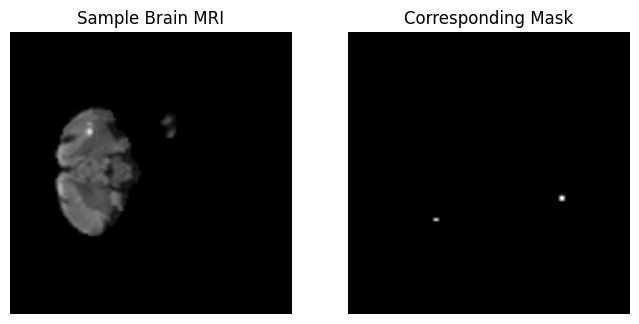

In [ ]:
# Image Preprocessing
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Define fixed image size for models
IMG_SIZE = (224, 224)

# Paths to dataset
dataset_path = "/content/drive/MyDrive/BrainMRI"
categories = ["acute", "acute_mask", "normal", "normal_mask"]

# Function to load and preprocess images
def load_and_preprocess_images(folder):
    image_paths = [os.path.join(folder, img) for img in os.listdir(folder)]
    preprocessed_images = []

    for img_path in image_paths:
        # Read image
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Load as grayscale
        if img is None:
            continue  # Skip if image not found

        # Resize image
        img_resized = cv2.resize(img, IMG_SIZE)

        # Normalize pixel values to [0,1]
        img_normalized = img_resized / 255.0

        # Convert to 3-channel RGB (needed for deep learning models)
        img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_GRAY2RGB)

        preprocessed_images.append(img_rgb)

    return preprocessed_images

# Load images and masks
acute_images = load_and_preprocess_images(os.path.join(dataset_path, "acute"))
acute_masks = load_and_preprocess_images(os.path.join(dataset_path, "acute_mask"))
normal_images = load_and_preprocess_images(os.path.join(dataset_path, "normal"))
normal_masks = load_and_preprocess_images(os.path.join(dataset_path, "normal_mask"))

# Display a sample MRI and its corresponding mask
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(acute_images[0], cmap='gray')
plt.title("Sample Brain MRI")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(acute_masks[0], cmap='gray')
plt.title("Corresponding Mask")
plt.axis("off")

plt.show()

In [ ]:
!pip install albumentations

<ipython-input-8-f0307b395bfc>:13: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.3),  # Elastic distortion
<ipython-input-8-f0307b395bfc>:14: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3)  # Add Gaussian noise


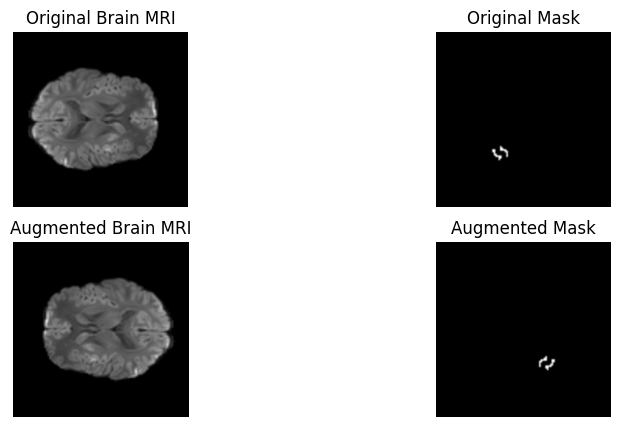

In [ ]:
import albumentations as A
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

# Define augmentation pipeline
augmentation = A.Compose([
    A.HorizontalFlip(p=0.5),                 # Random horizontal flip
    A.VerticalFlip(p=0.5),                   # Random vertical flip
    A.RandomRotate90(p=0.5),                 # Random 90-degree rotation
    A.RandomBrightnessContrast(p=0.2),       # Adjust brightness/contrast
    A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.3),  # Elastic distortion
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3)  # Add Gaussian noise
])

# Function to apply augmentation to an image and its mask
def augment_image(image, mask):
    augmented = augmentation(image=image, mask=mask)
    return augmented["image"], augmented["mask"]

# Select a random MRI image and its mask
idx = random.randint(0, len(acute_images) - 1)
original_image = acute_images[idx]
original_mask = acute_masks[idx]

# Apply augmentation
augmented_image, augmented_mask = augment_image(original_image, original_mask)

# Display original and augmented images
plt.figure(figsize=(10, 5))

plt.subplot(2, 2, 1)
plt.imshow(original_image, cmap='gray')
plt.title("Original Brain MRI")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(original_mask, cmap='gray')
plt.title("Original Mask")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(augmented_image, cmap='gray')
plt.title("Augmented Brain MRI")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(augmented_mask, cmap='gray')
plt.title("Augmented Mask")
plt.axis("off")

plt.show()

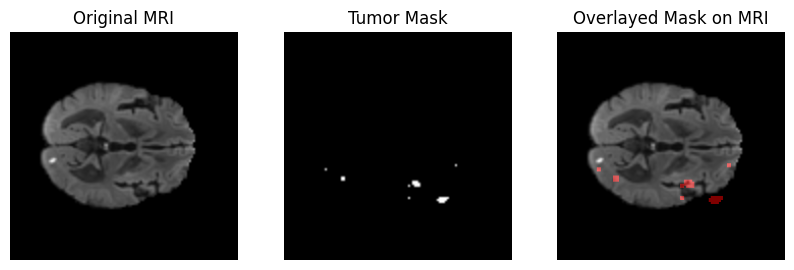

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Function to overlay mask on MRI image
def overlay_mask(image, mask, color=(255, 0, 0), alpha=0.5):
    """
    Overlay a segmentation mask onto an image.

    - image: Original MRI scan (grayscale or RGB)
    - mask: Segmentation mask (grayscale or RGB)
    - color: Color for overlay (default: red)
    - alpha: Transparency level of the overlay (0-1)
    """
    # Convert mask to grayscale if it's RGB
    if len(mask.shape) == 3:
        mask = cv2.cvtColor(mask, cv2.COLOR_RGB2GRAY)

    # Ensure mask is binary (0 or 1)
    mask = (mask > 0).astype(np.uint8)

    # Convert grayscale MRI to RGB if needed
    if len(image.shape) == 2:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

    # Create a colored version of the mask
    colored_mask = np.zeros_like(image)
    colored_mask[:, :, 0] = mask * color[0]  # Red channel
    colored_mask[:, :, 1] = mask * color[1]  # Green channel
    colored_mask[:, :, 2] = mask * color[2]  # Blue channel

    # Blend the image with the mask overlay
    overlayed_image = cv2.addWeighted(image, 1, colored_mask, alpha, 0)

    return overlayed_image

# Select a sample MRI and its corresponding mask
idx = np.random.randint(len(acute_images))  # Pick a random index
sample_mri = acute_images[idx]
sample_mask = acute_masks[idx]

# Overlay mask onto MRI
overlayed_image = overlay_mask(sample_mri, sample_mask)

# Display results
plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.imshow(sample_mri, cmap='gray')
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sample_mask, cmap='gray')
plt.title("Tumor Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlayed_image)
plt.title("Overlayed Mask on MRI")
plt.axis("off")

plt.show()

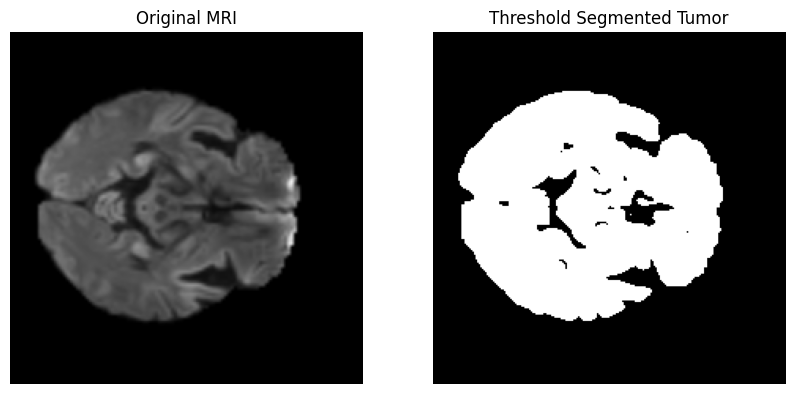

In [ ]:
# Thresholding for Tumor Segmentation
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Function for threshold-based segmentation
def threshold_segmentation(image):
    """
    Applies Otsu's thresholding to segment tumor regions.
    - image: Grayscale MRI scan
    """
    # Convert to grayscale (in case it's RGB)
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Apply Otsu's thresholding
    _, binary_mask = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    return binary_mask

# Select a sample MRI
idx = np.random.randint(len(acute_images))  # Pick a random MRI
sample_mri = acute_images[idx]

# Apply threshold segmentation
segmented_mask = threshold_segmentation(sample_mri)

# Display results
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(sample_mri, cmap='gray')
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(segmented_mask, cmap='gray')
plt.title("Threshold Segmented Tumor")
plt.axis("off")

plt.show()

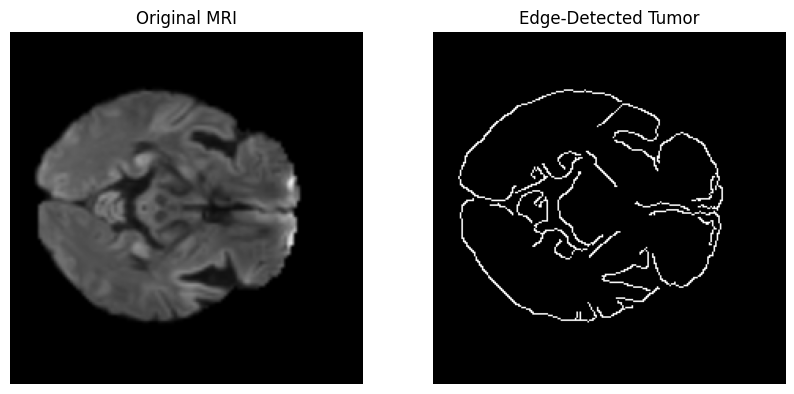

In [ ]:
# Edge Detection (Canny) for Tumor Boundary
# Function for edge-based segmentation
def edge_segmentation(image):
    """
    Applies Canny edge detection to extract tumor boundaries.
    - image: Grayscale MRI scan
    """
    # Convert to grayscale
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Apply Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(image, (5, 5), 0)

    # Apply Canny edge detection
    edges = cv2.Canny(blurred, 50, 150)

    return edges

# Apply edge segmentation
edge_mask = edge_segmentation(sample_mri)

# Display results
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(sample_mri, cmap='gray')
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(edge_mask, cmap='gray')
plt.title("Edge-Detected Tumor")
plt.axis("off")

plt.show()

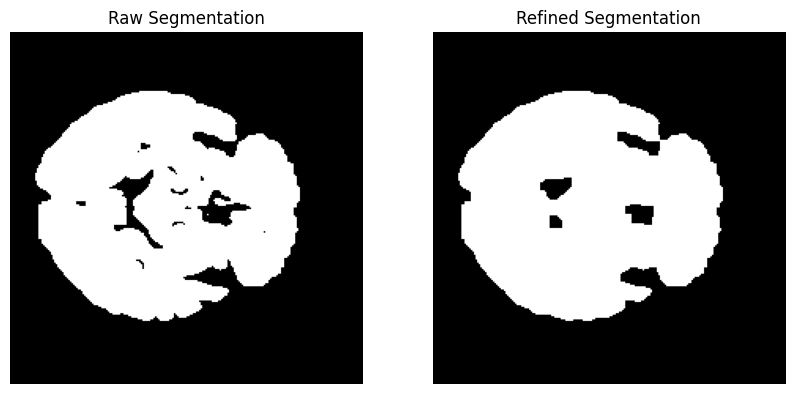

In [ ]:
# Morphological Operations for Refinement
# Function to refine segmentation using morphology
def refine_segmentation(mask):
    """
    Uses morphological operations to clean up segmented masks.
    - mask: Binary tumor mask
    """
    kernel = np.ones((3, 3), np.uint8)  # Define kernel size
    refined_mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)  # Closing operation
    return refined_mask

# Refine the threshold-based mask
refined_mask = refine_segmentation(segmented_mask)

# Display results
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(segmented_mask, cmap='gray')
plt.title("Raw Segmentation")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(refined_mask, cmap='gray')
plt.title("Refined Segmentation")
plt.axis("off")

plt.show()

In [ ]:
!pip install tensorflow keras

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D, concatenate, Input
from tensorflow.keras.optimizers import Adam
import cv2
import matplotlib.pyplot as plt

Loaded 200 images and 200 masks.


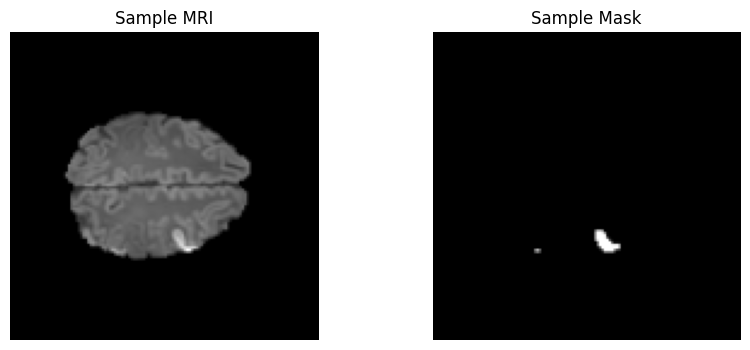

In [ ]:
# Define image size for U-Net
IMG_SIZE = (128, 128)

# Paths to dataset
dataset_path = "/content/drive/MyDrive/BrainMRI"
categories = ["acute", "acute_mask"]

# Function to load and preprocess images
def load_images_and_masks():
    images, masks = [], []

    mri_path = os.path.join(dataset_path, "acute")
    mask_path = os.path.join(dataset_path, "acute_mask")

    for img_name in os.listdir(mri_path):
        img_path = os.path.join(mri_path, img_name)
        mask_path_full = os.path.join(mask_path, img_name)

        # Read MRI scan and mask
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path_full, cv2.IMREAD_GRAYSCALE)

        if img is None or mask is None:
            continue  # Skip if not found

        # Resize images
        img = cv2.resize(img, IMG_SIZE)
        mask = cv2.resize(mask, IMG_SIZE)

        # Normalize images
        img = img / 255.0
        mask = mask / 255.0  # Mask remains binary (0 or 1)

        # Expand dimensions for deep learning model
        img = np.expand_dims(img, axis=-1)
        mask = np.expand_dims(mask, axis=-1)

        images.append(img)
        masks.append(mask)

    return np.array(images), np.array(masks)

# Load dataset
X, Y = load_images_and_masks()
print(f"Loaded {len(X)} images and {len(Y)} masks.")

# Split dataset into train and test (80%-20%)
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Check sample image and mask
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(X_train[0].squeeze(), cmap='gray')
plt.title("Sample MRI")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(Y_train[0].squeeze(), cmap='gray')
plt.title("Sample Mask")
plt.axis("off")

plt.show()

In [ ]:
# Function to create U-Net model
def build_unet(input_size=(128, 128, 1)):
    inputs = Input(input_size)

    # Encoder
    conv1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    conv1 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = Conv2D(128, (3, 3), activation='relu', padding='same')(pool1)
    conv2 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    # Bottleneck
    conv3 = Conv2D(256, (3, 3), activation='relu', padding='same')(pool2)
    conv3 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv3)

    # Decoder
    up1 = UpSampling2D(size=(2, 2))(conv3)
    up1 = concatenate([up1, conv2], axis=-1)
    conv4 = Conv2D(128, (3, 3), activation='relu', padding='same')(up1)
    conv4 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv4)

    up2 = UpSampling2D(size=(2, 2))(conv4)
    up2 = concatenate([up2, conv1], axis=-1)
    conv5 = Conv2D(64, (3, 3), activation='relu', padding='same')(up2)
    conv5 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv5)

    # Output Layer
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(conv5)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=Adam(), loss="binary_crossentropy", metrics=["accuracy"])

    return model

# Build U-Net
unet_model = build_unet()
unet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 1)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 128, 128, 64)   │            640 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 128, 128, 64)   │         36,928 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 64, 64, 64)     │              0 │ conv2d_1[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 64, 64, 128)    │         73,856 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 64, 64, 128)    │        147,584 │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 32, 32, 128)    │              0 │ conv2d_3[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 32, 32, 256)    │        295,168 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 32, 32, 256)    │        590,080 │ conv2d_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ up_sampling2d             │ (None, 64, 64, 256)    │              0 │ conv2d_5[0][0]         │
│ (UpSampling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 64, 64, 384)    │              0 │ up_sampling2d[0][0],   │
│                           │                        │                │ conv2d_3[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 64, 64, 128)    │        442,496 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 64, 64, 128)    │        147,584 │ conv2d_6[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ up_sampling2d_1           │ (None, 128, 128, 128)  │              0 │ conv2d_7[0][0]         │
│ (UpSampling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_1             │ (None, 128, 128, 192)  │              0 │ up_sampling2d_1[0][0], │
│ (Concatenate)             │                        │                │ conv2d_1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)         │ (None, 128, 128, 64)   │        110,656 │ concatenate_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)    

 Total params: 1,881,985 (7.18 MB)

 Trainable params: 1,881,985 (7.18 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history = unet_model.fit(X_train, Y_train,
                         validation_data=(X_test, Y_test),
                         batch_size=8, epochs=20)

# Save model
unet_model.save("/content/drive/MyDrive/BrainMRI/unet_model.h5")

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 204s 10s/step - accuracy: 0.9925 - loss: 0.2965 - val_accuracy: 0.9959 - val_loss: 0.0162
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 200s 10s/step - accuracy: 0.9962 - loss: 0.0165 - val_accuracy: 0.9959 - val_loss: 0.0148
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 200s 10s/step - accuracy: 0.9962 - loss: 0.0134 - val_accuracy: 0.9959 - val_loss: 0.0137
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 196s 10s/step - accuracy: 0.9962 - loss: 0.0121 - val_accuracy: 0.9959 - val_loss: 0.0130
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 193s 9s/step - accuracy: 0.9962 - loss: 0.0120 - val_accuracy: 0.9959 - val_loss: 0.0112
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 210s 10s/step - accuracy: 0.9961 - loss: 0.0100 - val_accuracy: 0.9959 - val_loss: 0.0092
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 202s 10s/step - accuracy: 0.9963 - loss: 0.0082 - val_accuracy: 0.9959 - val_loss: 0.0077
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 204s 10s/step - accuracy: 0.9963 - loss: 0.0072 - val_accuracy: 0.9

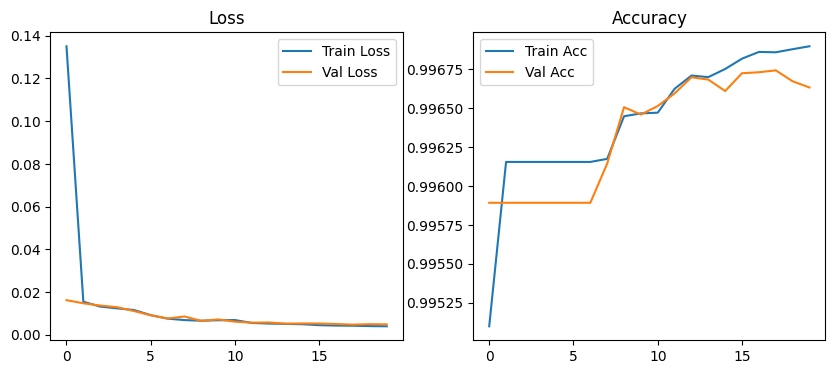

In [ ]:
plt.figure(figsize=(10, 4))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.legend()
plt.title("Loss")

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.legend()
plt.title("Accuracy")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 943ms/step


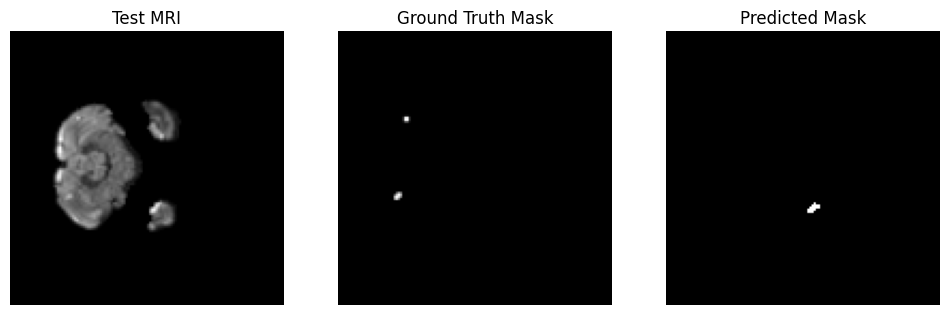

In [ ]:
# Select a test MRI image
idx = np.random.randint(len(X_test))
test_mri = X_test[idx]
test_mask = Y_test[idx]

# Predict segmentation mask
predicted_mask = unet_model.predict(np.expand_dims(test_mri, axis=0))[0]

# Threshold prediction to binary mask
predicted_mask = (predicted_mask > 0.5).astype(np.uint8)

# Display results
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(test_mri.squeeze(), cmap='gray')
plt.title("Test MRI")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(test_mask.squeeze(), cmap='gray')
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(predicted_mask.squeeze(), cmap='gray')
plt.title("Predicted Mask")
plt.axis("off")

plt.show()


Loaded 380 MRI images for classification.


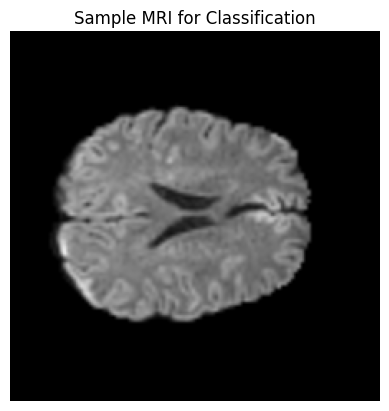

In [ ]:
import os
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, ResNet101, MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

# Define image size for deep learning models
IMG_SIZE = (224, 224)

# Paths to dataset
dataset_path = "/content/drive/MyDrive/BrainMRI"
categories = ["acute", "normal"]  # Class labels

# Function to load and preprocess images
def load_classification_data():
    images, labels = [], []

    for label, category in enumerate(categories):
        path = os.path.join(dataset_path, category)

        for img_name in os.listdir(path):
            img_path = os.path.join(path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Load grayscale MRI
            if img is None:
                continue

            img = cv2.resize(img, IMG_SIZE)  # Resize to 224x224
            img = img / 255.0  # Normalize
            img = np.expand_dims(img, axis=-1)  # Expand dimensions for CNNs

            images.append(img)
            labels.append(label)  # 0: Acute (Tumor), 1: Normal (No Tumor)

    return np.array(images), np.array(labels)

# Load dataset
X, Y = load_classification_data()
print(f"Loaded {len(X)} MRI images for classification.")

# Split into train & test sets (80%-20%)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Convert grayscale to 3 channels (for ResNet & MobileNet)
X_train = np.repeat(X_train, 3, axis=-1)
X_test = np.repeat(X_test, 3, axis=-1)

# Check sample MRI image
plt.imshow(X_train[0], cmap="gray")
plt.title("Sample MRI for Classification")
plt.axis("off")
plt.show()

In [ ]:
# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

# Augment training images
train_generator = datagen.flow(X_train, Y_train, batch_size=32)

In [ ]:
# Load pre-trained MobileNetV2
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")

# Add custom layers
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation="relu")(x)
output = Dense(1, activation="sigmoid")(x)  # Binary classification

# Create model
mobilenet_model = Model(inputs=base_model.input, outputs=output)
mobilenet_model.compile(optimizer=Adam(learning_rate=0.0001), loss="binary_crossentropy", metrics=["accuracy"])

# Train model
history_mobilenet = mobilenet_model.fit(train_generator, validation_data=(X_test, Y_test), epochs=10)

# Save model
mobilenet_model.save("/content/drive/MyDrive/BrainMRI/mobilenet_model.h5")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 108s 7s/step - accuracy: 0.6229 - loss: 0.6690 - val_accuracy: 0.5526 - val_loss: 0.7887
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 71s 7s/step - accuracy: 0.9148 - loss: 0.2629 - val_accuracy: 0.6053 - val_loss: 0.6843
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 69s 7s/step - accuracy: 0.9018 - loss: 0.2094 - val_accuracy: 0.6579 - val_loss: 0.5638
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 66s 7s/step - accuracy: 0.9532 - loss: 0.1597 - val_accuracy: 0.5921 - val_loss: 0.7640
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 67s 7s/step - accuracy: 0.9610 - loss: 0.0829 - val_accuracy: 0.5526 - val_loss: 1.1243
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 67s 7s/step - accuracy: 0.9991 - loss: 0.0507 - val_accuracy: 0.5395 - val_loss: 1.4415
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 67s 7s/step - accuracy: 0.9994 - loss: 0.0441 - val_accuracy: 0.4868 - val_loss: 1.9029
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 65s 6s/step - accuracy: 0.9807 - loss: 0.0535 - val_accuracy: 0.5263 - val_loss

In [ ]:
# Function to create a ResNet model
def create_resnet(model_type="ResNet50"):
    if model_type == "ResNet50":
        base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    elif model_type == "ResNet101":
        base_model = ResNet101(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

    # Add custom layers
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(128, activation="relu")(x)
    output = Dense(1, activation="sigmoid")(x)  # Binary classification

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=Adam(learning_rate=0.0001), loss="binary_crossentropy", metrics=["accuracy"])

    return model

# Train ResNet50
resnet50_model = create_resnet("ResNet50")
history_resnet50 = resnet50_model.fit(train_generator, validation_data=(X_test, Y_test), epochs=10)

# Save model
resnet50_model.save("/content/drive/MyDrive/BrainMRI/resnet50_model.h5")

# Train ResNet101
resnet101_model = create_resnet("ResNet101")
history_resnet101 = resnet101_model.fit(train_generator, validation_data=(X_test, Y_test), epochs=10)

# Save model
resnet101_model.save("/content/drive/MyDrive/BrainMRI/resnet101_model.h5")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 317s 29s/step - accuracy: 0.7474 - loss: 0.5603 - val_accuracy: 0.5263 - val_loss: 0.7692
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 316s 28s/step - accuracy: 0.8986 - loss: 0.2627 - val_accuracy: 0.5263 - val_loss: 0.7110
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 265s 28s/step - accuracy: 0.9267 - loss: 0.1849 - val_accuracy: 0.5263 - val_loss: 0.7458
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 260s 26s/step - accuracy: 0.9323 - loss: 0.1413 - val_accuracy: 0.5263 - val_loss: 0.7725
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 267s 27s/step - accuracy: 0.9942 - loss: 0.0586 - val_accuracy: 0.5263 - val_loss: 0.7835
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 267s 27s/step - accuracy: 0.9860 - loss: 0.0567 - val_accuracy: 0.5263 - val_loss: 0.6814
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 267s 27s/step - accuracy: 0.9905 - loss: 0.0247 - val_accuracy: 0.6974 - val_loss: 0.6647
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 267s 27s/step -

171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 562s 47s/step - accuracy: 0.6300 - loss: 0.6724 - val_accuracy: 0.4737 - val_loss: 0.9384
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 444s 44s/step - accuracy: 0.8990 - loss: 0.2563 - val_accuracy: 0.4737 - val_loss: 0.9788
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 516s 46s/step - accuracy: 0.9509 - loss: 0.1212 - val_accuracy: 0.4737 - val_loss: 0.7690
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 452s 45s/step - accuracy: 0.9855 - loss: 0.0473 - val_accuracy: 0.4737 - val_loss: 0.7680
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 455s 46s/step - accuracy: 0.9943 - loss: 0.0342 - val_accuracy: 0.4737 - val_loss: 0.6969
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 457s 46s/step - accuracy: 0.9759 - loss: 0.0818 - val_accuracy: 0.6447 - val_loss: 0.6823
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 453s 46s/step - accuracy: 0.9843 - loss: 0.0502 - val_accuracy: 0.7500 - val_loss: 0.6776
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 451s 45s/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step


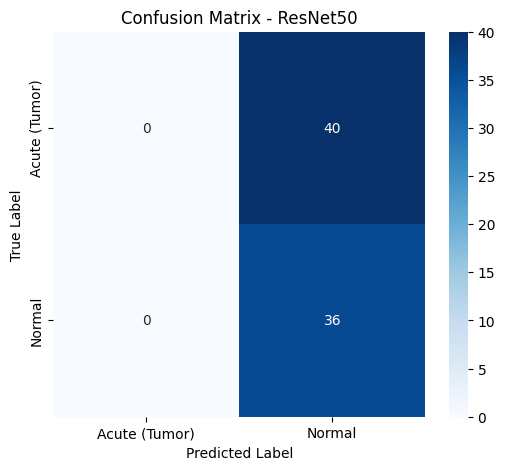

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        40
           1       0.47      1.00      0.64        36

    accuracy                           0.47        76
   macro avg       0.24      0.50      0.32        76
weighted avg       0.22      0.47      0.30        76



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Predict on test data
y_pred = resnet50_model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(Y_test, y_pred)

# Display confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Acute (Tumor)", "Normal"], yticklabels=["Acute (Tumor)", "Normal"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - ResNet50")
plt.show()

# Classification report
print(classification_report(Y_test, y_pred))

In [ ]:
def predict_mri_classification(image_path, model):
    """
    Predicts whether an MRI has a tumor (Acute) or is Normal.
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (224, 224)) / 255.0
    img = np.expand_dims(img, axis=-1)  # Expand for model
    img = np.repeat(img, 3, axis=-1)  # Convert to 3-channel

    prediction = model.predict(np.expand_dims(img, axis=0))
    return "Acute (Tumor Detected)" if prediction > 0.5 else "Normal (No Tumor)"

# Example prediction
test_image_path = "/content/drive/MyDrive/BrainMRI/acute/303.png"
print(predict_mri_classification(test_image_path, resnet50_model))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step
Acute (Tumor Detected)
